In [1]:
import os
# Disable tokenizers parallelism
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install git+https://github.com/csebuetnlp/normalizer
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.4 MB/s eta 0:00:00
  Cloning https://github.com/csebuetnlp/normalizer to /tmp/pip-req-build-7gqk6pzp
  Running command git clone --filter=blob:none --quiet https://github.com/csebuetnlp/normalizer /tmp/pip-req-build-7gqk6pzp
  Resolved https://github.com/csebuetnlp/normalizer to commit d405944dde5ceeacb7c2fd3245ae2a9dea5f35c9
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for normalizer: filename=normalizer-0.0.1-py3-none-any.whl size=6860 sha256=7cee142d3bce0e5b2460b5127aac19b7eaef119097cdbeef5f0220a78fd53a9d
  Stored in directory: /tmp/pip-ephem-wheel-cache-vf2ck7z4/wheels/2e/79/9c/cd96d490298305d51d2da11484bb2c25fd1f759a6906708282
  Created wheel for emoji: filename=emoji-1.4

In [3]:
import pandas as pd
from collections import Counter
import re
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
import evaluate
# from datasets import load_metric
import datasets
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
from datasets import Dataset, DatasetDict
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import random
np.object = object
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoTokenizer, DataCollatorWithPadding,BertModel,AutoTokenizer,AutoConfig,RobertaModel
from collections import defaultdict
import torch
import warnings
warnings.filterwarnings('ignore')
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from transformers import AdamW
from sklearn.model_selection import KFold
from torch.cuda import amp

import gc
gc.enable()

In [4]:
def set_random_seed(random_seed):
    random.seed(random_seed)
    np.random.seed(random_seed)
    os.environ["PYTHONHASHSEED"] = str(random_seed)

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)

    torch.backends.cudnn.deterministic = True

In [5]:
df = pd.read_csv("/kaggle/input/bengali-pharmaceutical-reviews/LargePharmaVal.csv")

In [6]:
with pd.option_context('display.max_colwidth',0):
    display(df.sample(n=10))

,Reviews,category,Label,Length,Word Count
2909,"পুরাই লস ভাই। সেলার বললেন ম্যাশিনের ব্যাটারি ঠিক আছে কিন্তু আমি পেলাম নষ্ট, কেন!",medical_kits,2,81,14
3397,"মাস্ক নিয়ে তেমন খুশি না। কোয়ালিটি তেমন একটা ভালো না, ডেলিভারি দিতে অনেক দেরি করলো",medical_kits,2,83,15
1369,মাশাআল্লাহ মাশাআল্লাহ সেরা কোয়ালিটি 😊! দ্রুত ডেলিভারি পেয়েছি 👌। সেলার ভাই খুব সৎ আছেন হানড্রেড পারসেন্ট রেকমেন্ডেড ❤️,adult_items,5,119,18
5830,"বাজে অভিজ্ঞতা। ওষুধ ছবির চেয়ে বাস্তবে খারাপ 😡😡 অর্ডার করেছিলাম 3টা, পেলাম 2টা কেউ যেন এই দোকান থেকে না কেনে",medicines,1,108,20
8784,"মাথায় চুল কম তাই শ্যাম্পু দিই। উন্নতি হয়েছে কিছু তবে তেমন না, অভিজ্ঞতা ভালো আরকি না।",Random/Misc,3,84,16
581,"দাম তুলনামূলক কম। সাপ্লিমেন্ট নিয়ে কিছু মাইনর ইস্যু আছে। দাম একটু বেশি, তবে মান ভালো",body_fitness,4,85,15
3795,"নেবুলাইজার মোটামুটি। মন্দের ভালো, ডেলিভারি ম্যান একটু দেরী করেছে",medical_kits,3,64,9
8147,নেবুলাইজার মোটামুটি ভালো। তবে মোটামুটি ভালো,medical_kits,3,43,6
8962,কিসব বালের সিরাপ বিক্রি করে ডেট নাই। বাচ্চাকে খাওয়ালাম কান্না থামে না শালা বাটপার ভণ্ড । তোর ব্যবসার লাল বাতি আমি জ্বালাবো।,Random/Misc,1,123,22
7204,"মাস্ক গুলো খুবই দারূন। আর সাথে একটি Kn95 গিফট হিসাবে পাওয়া অসাধারণ। মাস্ক গুলো পড়েই অনেক স্বস্তি লাগে।\nকালো রঙের মাস্ক গুলো খুবই আরামদায়ক, ব্যবহার করে ভালোই লাগছে, একটা বিষয়ে খুবই খুশি হয়েছি, পেকেটের মধ্যে একটা কে ৯৫ মাস্ক গিফট হিসাবে পেয়ে..",medical_kits,5,241,42


In [7]:
df.shape

(9515, 5)

In [8]:
df.shape[0]*0.7

6660.5

In [9]:
df["Label"].value_counts()

Label
5    2238
1    2199
4    1989
2    1563
3    1526
Name: count, dtype: int64

In [10]:
df["Label"] = df["Label"] - 1
df["Label"].value_counts()

Label
4    2238
0    2199
3    1989
1    1563
2    1526
Name: count, dtype: int64

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x,fig_y,col,top_x,rotation,xlabel,title) :
    plt.figure(figsize=(fig_x,fig_y))
    total = float(len(df))
    ax = sns.countplot(x=col,  data=df, order = df[col].value_counts().iloc[:top_x].index) 
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y),xytext = (x+0.05,y+20),ha = 'center',weight = 'bold',size = 11)
    plt.xticks(rotation = rotation,weight='bold',size = 10)
    plt.yticks(weight='bold',size = 10)
    plt.xlabel(xlabel,weight='bold',size = 12)
    plt.ylabel('count',weight='bold',size = 12)
    plt.title(title,weight='bold',size = 15)
    plt.show()

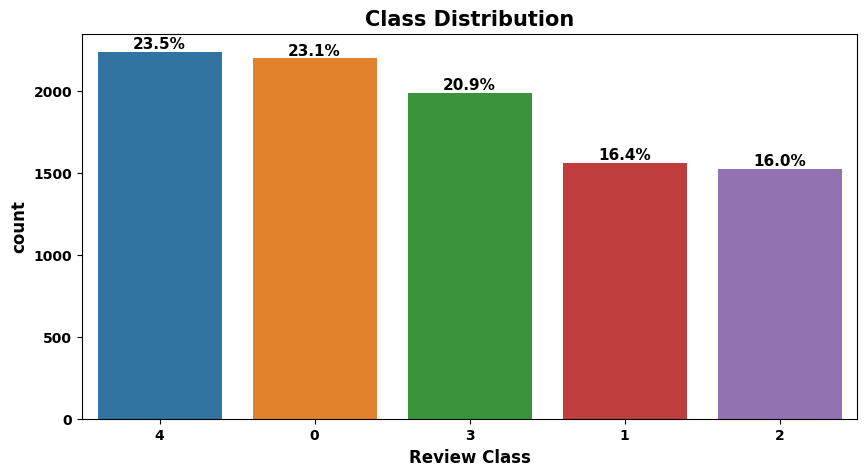

In [12]:
countplot(10,5,'Label',15,0,'Review Class','Class Distribution')

In [13]:
from sklearn.model_selection import train_test_split

# Step 1: Split the data into train and temp (test + validation) sets
X_train, X_test1, y_train, y_test1 = train_test_split(df['Reviews'], df['Label'], test_size=0.3, random_state=42, stratify=df['Label'])

# Step 2: Split the temp set into validation and test sets (10% validation, 20% test)
X_val, X_test, y_val, y_test = train_test_split(X_test1,y_test1, test_size=2/3, random_state=42, stratify=y_test1)

In [14]:
X_train.shape

(6660,)

In [15]:
train_df = pd.DataFrame()
train_df['text'] = X_train.values
train_df['label'] = y_train.values


In [16]:
val_df = pd.DataFrame()
val_df['text'] = X_val.values
val_df['label'] = y_val.values

In [17]:
test_df = pd.DataFrame()
test_df['text'] = X_test.values
test_df['label'] = y_test.values

In [18]:
train_df.shape

(6660, 2)

In [19]:
train_df.head()

,text,label
0,১০০% অরিজিনাল প্রোডাক্ট! খুব উন্নত মানের প্রোড...,4
1,আলহামদুলিল্লাহ অনেক অনেক ভালো লেগেছে 😍। সুন্দর...,4
2,প্রথম প্রথম ব্যবহার করে খুব ভালো ফল পেয়েছিলাম ...,2
3,অসংখ্য ধন্যবাদ সেলারকে। তিনি কারেন্ট ডেটের এবং...,4
4,৫০ টা মাস্কের অনেক গুলায় নাকে ফিট করার স্টিল ট...,2


In [20]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1904 non-null   object
 1   label   1904 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 29.9+ KB


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x,fig_y,col,top_x,rotation,xlabel,title) :
    plt.figure(figsize=(fig_x,fig_y))
    total = float(len(train_df))
    ax = sns.countplot(x=col,  data=train_df, order = train_df[col].value_counts().iloc[:top_x].index) 
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y),xytext = (x+0.05,y+20),ha = 'center',weight = 'bold',size = 11)
    plt.xticks(rotation = rotation,weight='bold',size = 10)
    plt.yticks(weight='bold',size = 10)
    plt.xlabel(xlabel,weight='bold',size = 12)
    plt.ylabel('count',weight='bold',size = 12)
    plt.title(title,weight='bold',size = 15)
    plt.show()

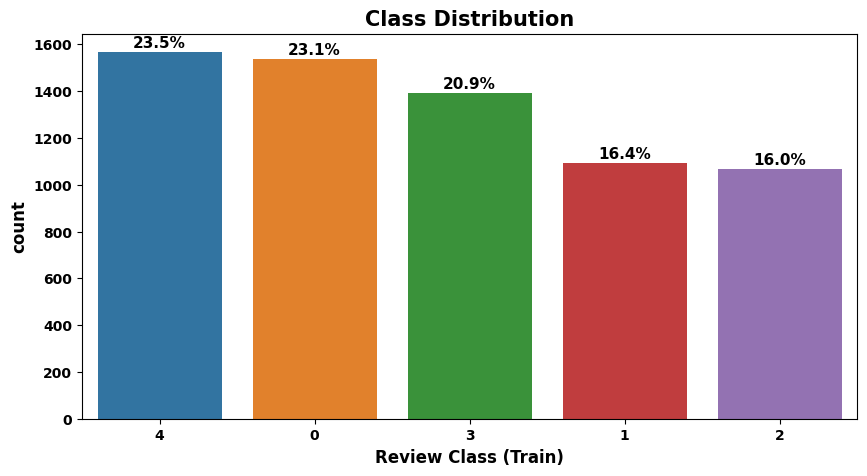

In [22]:
countplot(10,5,'label',15,0,'Review Class (Train)','Class Distribution')

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x,fig_y,col,top_x,rotation,xlabel,title) :
    plt.figure(figsize=(fig_x,fig_y))
    total = float(len(val_df))
    ax = sns.countplot(x=col,  data=val_df, order = val_df[col].value_counts().iloc[:top_x].index) 
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y),xytext = (x+0.05,y+20),ha = 'center',weight = 'bold',size = 11)
    plt.xticks(rotation = rotation,weight='bold',size = 10)
    plt.yticks(weight='bold',size = 10)
    plt.xlabel(xlabel,weight='bold',size = 12)
    plt.ylabel('count',weight='bold',size = 12)
    plt.title(title,weight='bold',size = 15)
    plt.show()

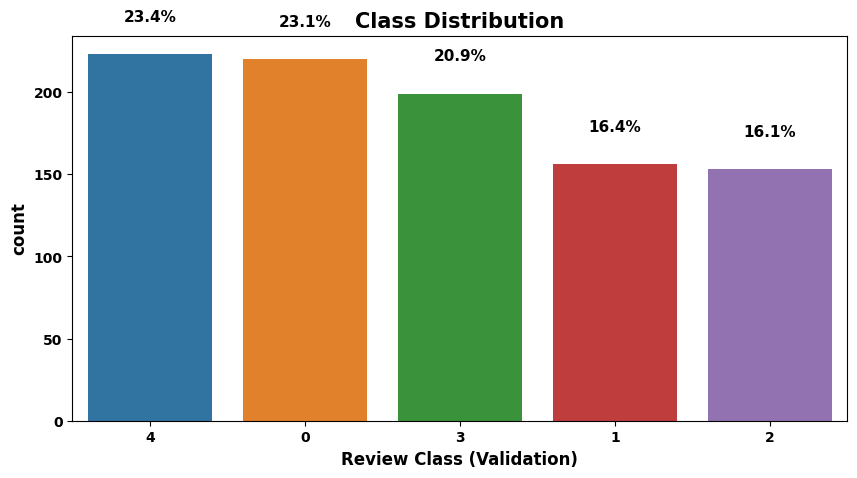

In [24]:
countplot(10,5,'label',15,0,'Review Class (Validation)','Class Distribution')

In [25]:
from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [26]:
class Config:
    num_classes = 5
    path =  "bert-base-multilingual-uncased"
    num_epochs = 10
    batch_size = 32
    SEED = 42
    learning_rate = 2e-5
    device = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()

In [27]:
tokenizer = AutoTokenizer.from_pretrained(config.path)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

<Axes: ylabel='Count'>

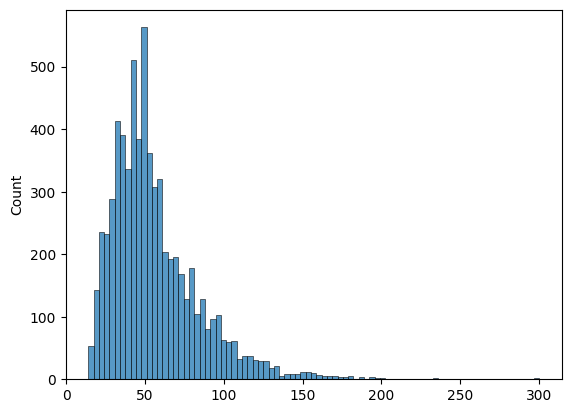

In [28]:
token_counts = []
for _, row in train_df.iterrows():
    token_count = len(tokenizer.encode(
    row["text"],
    max_length=512,
    truncation=True
  ))
    token_counts.append(token_count)

sns.histplot(token_counts)

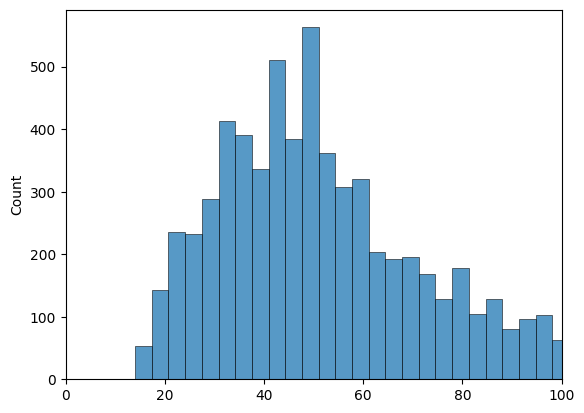

In [29]:
sns.histplot(token_counts)
plt.xlim([0, 100]);

<Axes: ylabel='Count'>

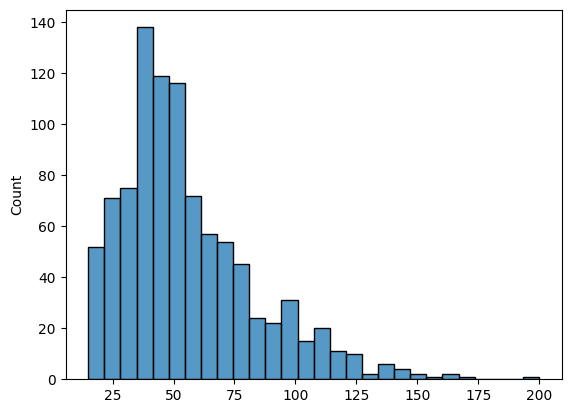

In [30]:
token_counts = []
for _, row in val_df.iterrows():
    token_count = len(tokenizer.encode(
    row["text"],
    max_length=512,
    truncation=True
  ))
    token_counts.append(token_count)

sns.histplot(token_counts)

In [31]:
max(token_counts)

200

<Axes: ylabel='Count'>

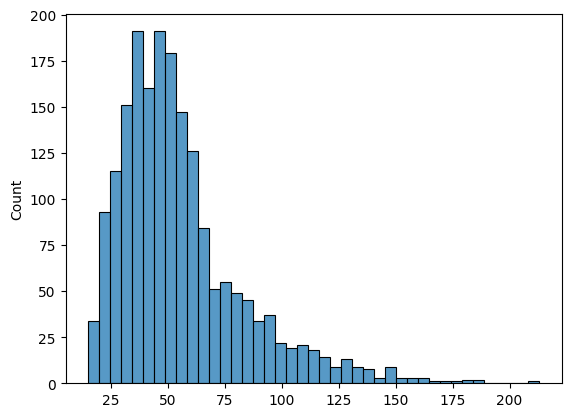

In [32]:
token_counts = []
for _, row in test_df.iterrows():
    token_count = len(tokenizer.encode(
    row["text"],
    max_length=512,
    truncation=True
  ))
    token_counts.append(token_count)

sns.histplot(token_counts)

In [33]:
max(token_counts)

213

In [34]:
max_token_length = 120
def tokenize_function(example):
    return tokenizer(example["text"], padding = True, truncation=True, max_length=max_token_length)

# mapping dataset (actually texts) into tokenized values of pretrained model (provided in path)
tokenized_train_datasets = train_dataset.map(tokenize_function, batched=True)
tokenized_val_datasets = val_dataset.map(tokenize_function, batched=True)
tokenized_test_datasets = test_dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/6660 [00:00<?, ? examples/s]

Map:   0%|          | 0/951 [00:00<?, ? examples/s]

Map:   0%|          | 0/1904 [00:00<?, ? examples/s]

In [35]:
tokenized_train_datasets

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6660
})

In [36]:
tokenized_val_datasets

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 951
})

In [37]:
tokenized_test_datasets

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1904
})

In [38]:
tokenized_train_datasets = tokenized_train_datasets.remove_columns(['text', 'token_type_ids'])
tokenized_val_datasets = tokenized_val_datasets.remove_columns(['text', 'token_type_ids'])
tokenized_test_datasets = tokenized_test_datasets.remove_columns(['text', 'token_type_ids'])
tokenized_train_datasets.set_format("torch")
tokenized_val_datasets.set_format("torch")
tokenized_test_datasets.set_format("torch")

In [39]:
tokenized_test_datasets.column_names

['label', 'input_ids', 'attention_mask']

In [40]:
# class ClassifierModel(nn.Module):

#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.bert = BertModel.from_pretrained(config.path)
#         self.drop = nn.Dropout(p=0.45)
#         self.out = nn.Linear(768, config.num_classes)

#     def forward(self, input_ids, attention_mask):
#         output = self.bert(
#             input_ids = input_ids,
#             attention_mask = attention_mask
#         )

#         x = self.drop(output[1])

#         return self.out(x)

# '''XLM-R Model'''
# from transformers import XLNetModel, XLNetTokenizer

# class ClassifierModel(nn.Module):

#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.xlnet = XLNetModel.from_pretrained(config.path)
#         self.drop = nn.Dropout(p=0.30)
#         self.out = nn.Linear(768, config.num_classes)  

#     def forward(self, input_ids, attention_mask):
#         # XLNet returns two outputs: the last hidden state and the pooled output (similar to BERT)
#         output = self.xlnet(
#             input_ids = input_ids,
#             attention_mask = attention_mask
#         )

#         # Take the first token's representation
#         cls_output = output.last_hidden_state[:, 0, :]  
#         x = self.drop(cls_output)

#         return self.out(x)


# '''ALBert Model'''
# from transformers import AlbertModel


# class ClassifierModel(nn.Module):

#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.albert = AlbertModel.from_pretrained(config.path)
#         self.drop = nn.Dropout(p=0.45)
#         self.out = nn.Linear(768, config.num_classes) 

#     def forward(self, input_ids, attention_mask):
#         output = self.albert(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )

#         pooled_output = output[1]  
#         x = self.drop(pooled_output)

#         return self.out(x)


'''mBERT Model'''
class ClassifierModel(nn.Module):
    def __init__(self, config):
        super(ClassifierModel, self).__init__()
        self.bert = BertModel.from_pretrained(config.path)
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(768, config.num_classes) 

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        pooled_output = outputs[1]
        x = self.dropout(pooled_output)

        return self.fc(x)

In [41]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score


class Engine:
    def __init__(self, model, optimizer,scheduler = None):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        
    @staticmethod
    def loss_fn(target, pred):
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(pred,target)
        return loss
    
    @staticmethod
    def compute_metrics(labels, pred):
        y_true = labels.cpu().numpy()
        pred = pred.cpu().numpy()
        y_pred = np.argmax(pred, axis = -1)
        f1 = f1_score(y_true, y_pred, average='macro')
        return f1
        
    def train(self, train_dataloader,scaler,num_training_steps):
        self.model.train()
        total_training_loss = 0.0
        DEVICE = config.device
        progress_bar = tqdm(range(num_training_steps))
        for data in train_dataloader:
            input_ids = data["input_ids"].to(DEVICE)
            attention_mask = data["attention_mask"].to(DEVICE)            
            target = data["labels"].to(DEVICE)
            self.optimizer.zero_grad()
            
            with amp.autocast():
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target,pred)
                
            total_training_loss += loss.item()
            scaler.scale(loss).backward()
            scaler.step(self.optimizer)
            scaler.update()
            if self.scheduler:
                self.scheduler.step()
            progress_bar.update(1)
                
        return total_training_loss / len(train_dataloader)
    
    def evaluate(self,eval_dataloader):
        self.model.eval()
        DEVICE = config.device
        val_loss = 0
        score = 0.0
        with torch.no_grad():
            for data in tqdm(eval_dataloader):
                input_ids = data["input_ids"].to(DEVICE)
                attention_mask = data["attention_mask"].to(DEVICE)            
                target = data["labels"].to(DEVICE)
                
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target,pred)
                val_loss += loss.item()
                batch_score = self.compute_metrics(target,pred)
                score+= batch_score
             
            score = score / len(eval_dataloader)
            val_loss = val_loss / len(eval_dataloader)
        
        return score, val_loss

In [42]:
from transformers import get_scheduler

def run_training(save_model = False):

    train_loader = DataLoader(tokenized_train_datasets, batch_size = config.batch_size,
                              collate_fn=data_collator, shuffle =True, num_workers=2)    
    val_loader = DataLoader(tokenized_val_datasets, batch_size = config.batch_size,
                            drop_last=False,collate_fn=data_collator, shuffle=False, num_workers=2)   
    set_random_seed(config.SEED)
    model = ClassifierModel(config)
    model.to(config.device)
    
#     optimizer = create_optimizer(model)  
    optimizer = torch.optim.AdamW(model.parameters(), lr = config.learning_rate, weight_decay=0.01)
    num_training_steps = config.num_epochs * len(train_loader)
    
    scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
    )
    eng = Engine(model, optimizer, scheduler)
    scaler = amp.GradScaler()
    early_stopping_iter = 5
    early_stopping_counter = 0
    best_score = 0.0
    for epoch in range(config.num_epochs):
        train_loss = eng.train(train_loader,scaler,num_training_steps)
        val_score,val_loss = eng.evaluate(val_loader)
        
        print(f" Epoch: {epoch + 1} | Training_loss: {round(train_loss,5)} | Val_loss: {round(val_loss,5)} | Val_Score: {round(val_score,5)}")
        
        if val_score > best_score:
            best_score = val_score
            
            if save_model:
                torch.save(model.state_dict(),f"mbert_model.bin")
        else:
            early_stopping_counter +=1
            
        if early_stopping_counter > early_stopping_iter:
            break
            
    del model
    gc.collect()
            
    return best_score

In [43]:
score = run_training(save_model = True)
print(f"Best Score: {score}")

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

  0%|          | 0/2090 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 1 | Training_loss: 0.80442 | Val_loss: 0.43613 | Val_Score: 0.82067


  0%|          | 0/2090 [00:00<?, ?it/s]

...

  0%|          | 0/2090 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7898ea840af0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7898ea840af0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

  0%|          | 0/30 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7898ea840af0><function _MultiProcessingDataLoaderIter.__del__ at 0x7898ea840af0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
self._shutdown_workers()    
self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():    
if w.is_alive():  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a

 Epoch: 10 | Training_loss: 0.02263 | Val_loss: 0.34917 | Val_Score: 0.89669
Best Score: 0.904212169839105


In [44]:
from torch.utils.data import DataLoader
test_dataloader = DataLoader(
    tokenized_test_datasets, batch_size=32, collate_fn=data_collator
)

In [45]:
device = config.device

In [46]:
model = ClassifierModel(config)

In [47]:
model_path = f"/kaggle/working/mbert_model.bin"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [48]:
model.to(device)

ClassifierModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [49]:
model.eval()
prediction = []
for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'])
        logits = outputs
        pred = torch.argmax(logits, dim=-1)
        prediction.extend(pred.cpu().numpy().tolist())

In [50]:
y_true = test_df.label.values
y_pred = prediction

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_true, y_pred))

[[415  13  10   1   1]
 [ 17 261  31   3   1]
 [  4  14 258  27   2]
 [  1   1  19 363  14]
 [  1   0   1  11 435]]


In [52]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

# Print classification report with 2 decimal points
print(classification_report(y_true, y_pred, digits=2))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Compute and print evaluation metrics as percentages
accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average='macro') * 100
recall = recall_score(y_true, y_pred, average='macro') * 100
f1 = f1_score(y_true, y_pred, average='macro') * 100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision (Macro): {precision:.2f}%")
print(f"Recall (Macro): {recall:.2f}%")
print(f"F1 Score (Macro): {f1:.2f}%")

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       440
           1       0.90      0.83      0.87       313
           2       0.81      0.85      0.83       305
           3       0.90      0.91      0.90       398
           4       0.96      0.97      0.97       448

    accuracy                           0.91      1904
   macro avg       0.90      0.90      0.90      1904
weighted avg       0.91      0.91      0.91      1904

Confusion Matrix:
[[415  13  10   1   1]
 [ 17 261  31   3   1]
 [  4  14 258  27   2]
 [  1   1  19 363  14]
 [  1   0   1  11 435]]
Accuracy: 90.97%
Precision (Macro): 90.32%
Recall (Macro): 90.12%
F1 Score (Macro): 90.18%


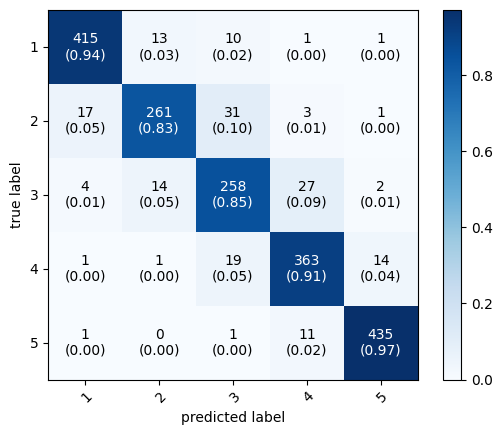

In [53]:
import torch
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
y_pred = torch.tensor(y_pred)
y_true = torch.tensor(y_true)

cmat = ConfusionMatrix(task="multiclass", num_classes=5)
confusion_matrix = cmat(y_pred, y_true)

fig, ax = plot_confusion_matrix(conf_mat=confusion_matrix.cpu().numpy(),
                                class_names=[1,2,3,4,5],
                                show_normed=True,
                                colorbar=True)

# Rotate the x-axis labels
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

# Show the plot
plt.show()